# Parametric Curve exploration - FLAM R&D Assignment

### The Problem 

How to find unkwown parameters theta, M, X given parametric equation and observed points?

By fitting the curve using those points!

### Code

##### Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##### Dataset Info

In [6]:
df = pd.read_csv("./data/xy_data.csv")
df.head()

,x,y
0,88.364456,57.784378
1,74.283936,54.406780
2,60.256474,46.311462
3,82.134370,57.717567
4,101.036390,67.849340


In [9]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       1500 non-null   float64
 1   y       1500 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB
None
                 x            y
count  1500.000000  1500.000000
mean     83.713931    58.263519
std      13.697157     7.696524
min      59.657204    46.032295
25%      72.282910    51.124211
50%      84.710995    57.681288
75%      93.368257    66.138374
max     109.231520    69.685510


Dataset : 1500 Observations with 2 columns - x & y. No value seem to be missing(indicated by the non-null characteristic of the columns) => This data can directly be used to fit the curve

##### Visualizing the Data

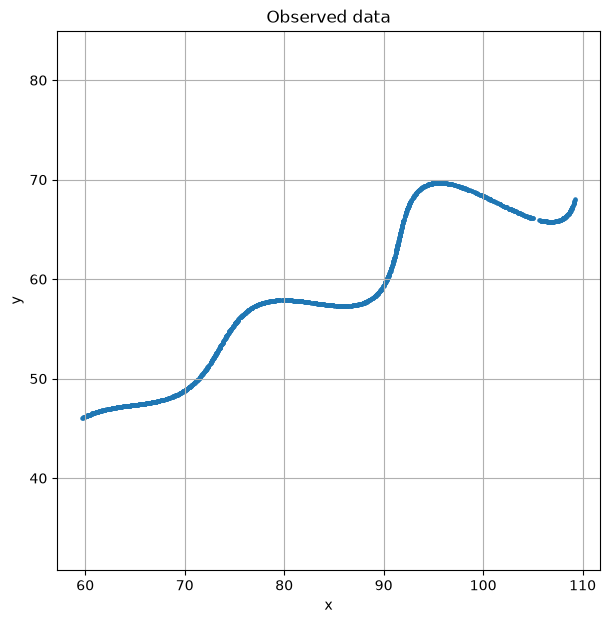

In [17]:
plt.figure(figsize=(7,7))

plt.scatter(df["x"], df["y"], s=5)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Observed data")

plt.axis("equal")
plt.grid(True)

plt.show()

The dataset was visualized using a scatter plot to understand its overall structure

From the above figure, we can infer
- The dataset consists of a **smooth, continous Trajectory**
- There are **no visible missing values or Outliers visible**
- The wave is **oscillating**, Maybe as a result of the sinusoidal component in our parametric equation
- The overall trajectory shows an increasing trend in both the x and y directions while maintaining periodic variations.
- Points are uniformly sampled along the curve

### Mathematical Model

The curve is represented by:

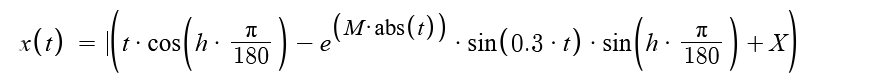

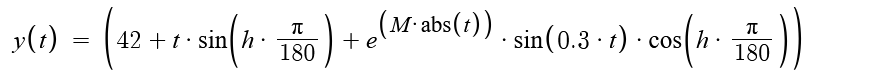

Note: The variable h is used in place of θ in desmos(Because Desmos is not allowing it to be used as an external slider parameter.

where:
- θ controls orientation of curve
- M controls the exponential component
- X controls horizontal translation

#### Implementation of the curve

In [23]:
def curve(t, theta, M, X):
    theta = np.radians(theta)
    
    x = (
        t*np.cos(theta) - np.exp(M*np.abs(t))*np.sin(0.3*t)*np.sin(theta) + X
    )
    
    y = (
        42
        + t*np.sin(theta)
        + np.exp(M*np.abs(t))*np.sin(0.3*t)*np.cos(theta)
    )

    return x,y

(1000,) (1000,)


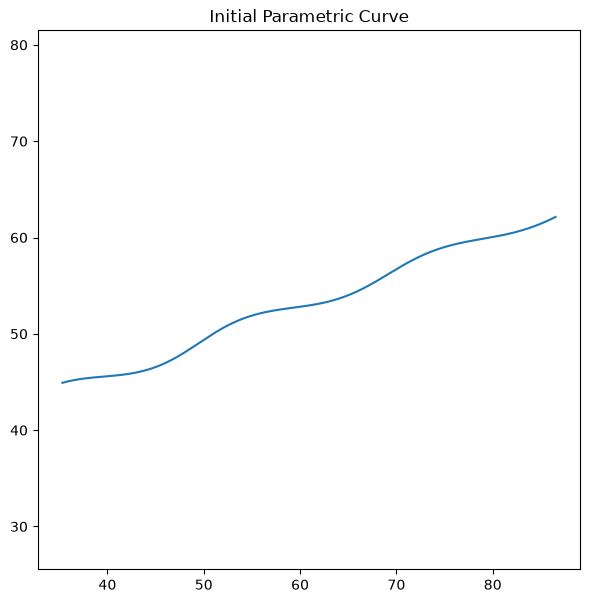

In [24]:
theta = 20
M = -0.01
X = 30

t = np.linspace(6,60,1000)

x,y = curve(t,theta,M,X)

plt.figure(figsize=(7,7))
print(x.shape,y.shape)

plt.plot(x,y)

plt.axis("equal")

plt.title("Initial Parametric Curve")

plt.show()

#### Parameter Exploration by plotting possible values of each parameter

##### **Effect of changing θ (rotation parameter)**

Let M = -0.01 and X = 30 and we will look through θ = 10deg, 20deg, 30deg, 40deg

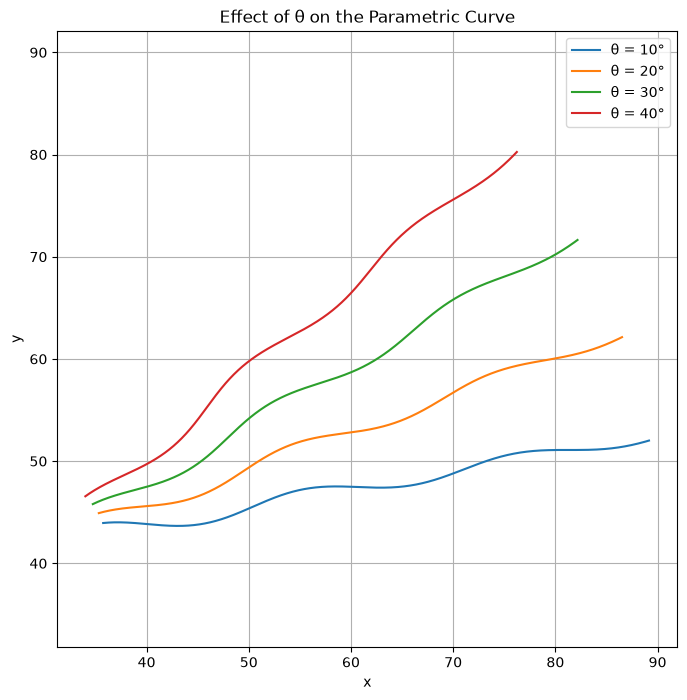

In [25]:
M = -0.01
X = 30

plt.figure(figsize=(8,8))

for theta in [10, 20, 30, 40]:
    x, y = curve(t, theta, M, X)
    plt.plot(x, y, label=f"θ = {theta}°")

plt.title("Effect of θ on the Parametric Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

**Observations**

- Increasing θ rotates the trajectory.
- The overall shape of the curve remains similar.

Therefore, θ primarily controls the **orientation of the curve.**

##### **Effect of changing M**

We fix theta and X while varying M

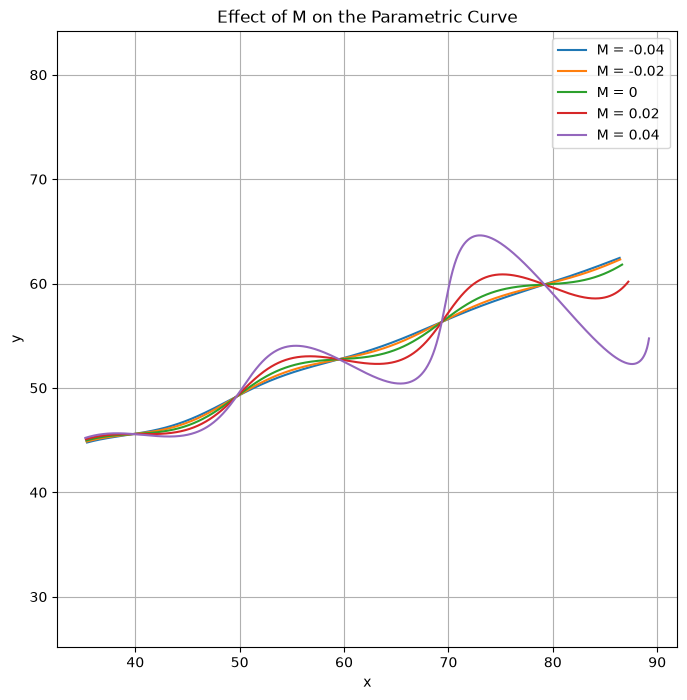

In [26]:
theta = 20
X = 30

plt.figure(figsize=(8,8))

for M in [-0.04, -0.02, 0, 0.02, 0.04]:
    x, y = curve(t, theta, M, X)
    plt.plot(x, y, label=f"M = {M}")

plt.title("Effect of M on the Parametric Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

### Observations

- M seems to changes the exponential component of the equation.
- As M varies, the oscillatory behaviour changes gradually.

Therefore, M modifies the **shape of the curve** 

##### Effect of changing X (Horizontal Translation)

To investigate the effect of X, θ and M were kept constant while X was varied.

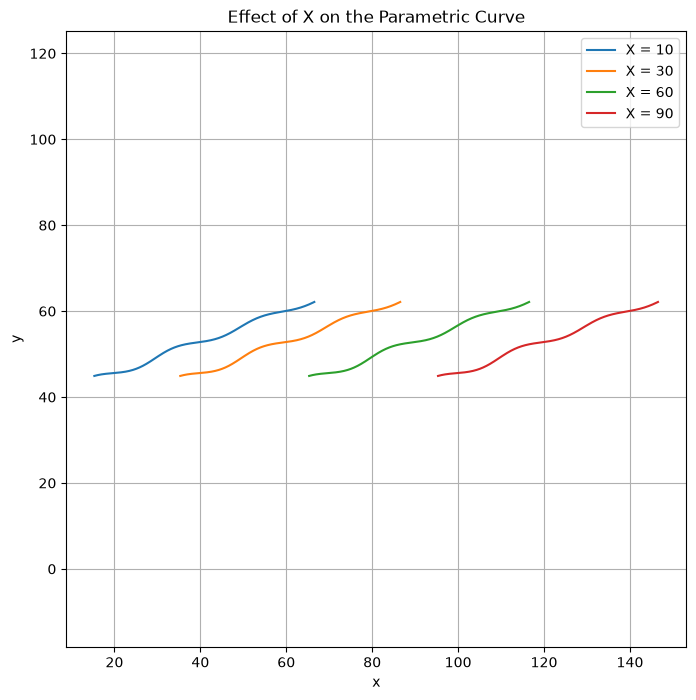

In [27]:
theta = 20
M = -0.01

plt.figure(figsize=(8,8))

for X in [10, 30, 60, 90]:
    x, y = curve(t, theta, M, X)
    plt.plot(x, y, label=f"X = {X}")

plt.title("Effect of X on the Parametric Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

### Observations

- Increasing X shifts the curve horizontally along the x-axis.
- The shape and oscillatory behaviour remain unchanged.
Therefore, X controls the **horizontal position of the curve.**

#### **Summary of Parameter Exploration**

The parameter exploration provided valuable insight into the behaviour of the mathematical model before optimization.

The following conclusions were drawn:

- **θ** primarily controls the orientation of the curve.
- **X** controls the horizontal translation of the curve.
- **M** affects the exponential component and changes the magnitude of the oscillations.

Understanding the individual influence of each parameter helped build intuition about the model and provided a foundation for the subsequent parameter estimation process.

## Using our dataset to compare

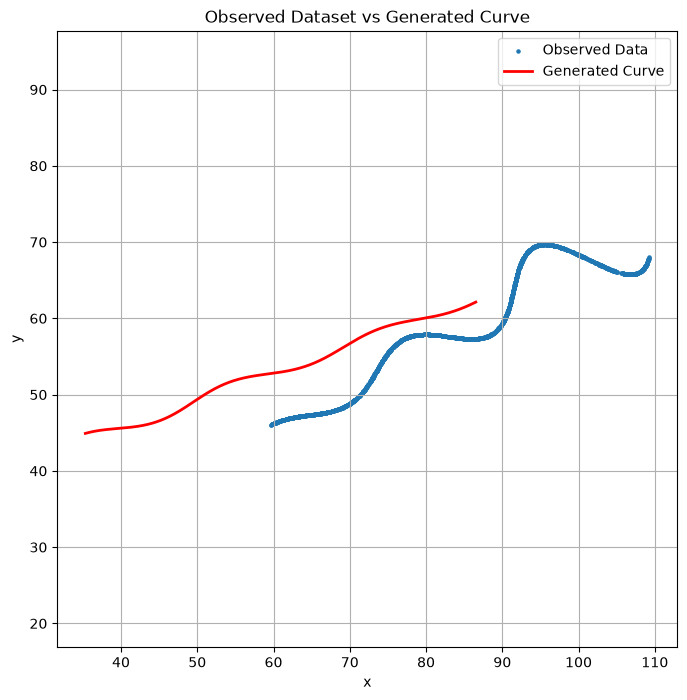

In [28]:
theta = 20
M = -0.01
X = 30

x_pred, y_pred = curve(t, theta, M, X)

plt.figure(figsize=(8,8))

plt.scatter(df["x"], df["y"], s=5, label="Observed Data")
plt.plot(x_pred, y_pred, color="red", linewidth=2, label="Generated Curve")

plt.title("Observed Dataset vs Generated Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

### Observations

- The generated curve follows a similar overall trend as the observed data.
- The predicted curve does not align perfectly with the observed trajectory.
- Differences are visible in both the position and shape of the curve.
- This indicates that manually selecting parameter values is insufficient for accurately modelling the dataset.
- A numerical optimization procedure is therefore required to estimate the unknown parameters.

# Loss Function

To estimate the unknown parameters (θ, M and X), a numerical measure is required to quantify the difference between the observed dataset and the generated curve.


**Simple Loss Function**

In [29]:
def loss(theta, M, X):

    t = np.linspace(6,60,len(df))

    x_pred, y_pred = curve(t, theta, M, X)

    error = (
        np.abs(df["x"].values - x_pred).sum()
        + np.abs(df["y"].values - y_pred).sum()
    )

    return error

# Optimization Strategy

Manually selecting parameter values is inefficient and does not guarantee an accurate fit.

Instead, a numerical optimization algorithm could be used.

1. We Generate a candidate set of parameters.
2. We Computes the generated curve using the generated set of parameters.
3. Evaluates the L1 loss for each one.
4. Updates the parameters to reduce the error using the l1 loss.

This process is continued until the minimum loss is reached.

#### Defining the Objective Function

The evaluation is based on the L1 distance between uniformly sampled points of the expected and predicted curves. Therefore, the optimization objective is to minimize the average absolute difference between corresponding observed and predicted coordinates.

Assuming that the dataset represents uniformly sampled points along the parameter t, the loss function is defined as

$$
L(\theta,M,X)
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(
|x_i-\hat{x}_i|
+
|y_i-\hat{y}_i|
\right)
$$

where:

- xi, yi are observed coordinates
- xi^, yi^ are coordinated generated by model
- N is number of sampled points

In [30]:
from optimize import optimize_curve

res = optimize_curve(df)

res

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 12.621698262915416
        x: [ 2.812e+01  2.139e-02  5.490e+01]
      nit: 24
      jac: [ 5.809e-05 -4.134e-02 -3.553e-07]
     nfev: 196
     njev: 49
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [31]:
theta_optim, M_optim, X_optim = res.x

print(theta_optim, M_optim, X_optim)

28.11900837576594 0.02138534670337698 54.89849119967482


In [32]:
print("Final Loss:", res.fun)

Final Loss: 12.621698262915416


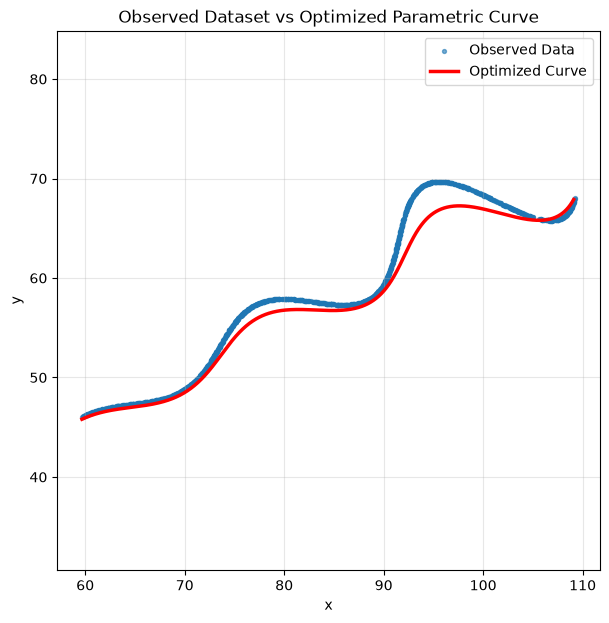

In [35]:
plt.figure(figsize=(7,7))

plt.scatter(
    df["x"],
    df["y"],
    s=8,
    alpha=0.6,
    label="Observed Data"
)

plt.plot(
    x,
    y,
    color="red",
    linewidth=2.5,
    label="Optimized Curve"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Observed Dataset vs Optimized Parametric Curve")

plt.legend()

plt.axis("equal")

plt.grid(alpha=0.3)

plt.show()

The optimized curve closely follows the overall trajectory of the observed dataset. The optimizer successfully captures the general orientation and oscillatory behaviour of the curve. Minor deviations remain in certain regions, suggesting that while the estimated parameters provide a good fit under the L1 objective, the model does not perfectly reproduce every point in the dataset.

# Results [ Estimated Parmeters ]

## Estimated Parameters

After minimizing the L1 objective function, the optimizer converged successfully and produced the following parameter estimates.

| Parameter | Estimated Value |
|-----------|----------------:|
| θ (degrees) | 28.1192 |
| M | 0.02113 |
| X | 56.8949 |

The final optimized L1 loss is

\[
L = 12.6216
\]

The successful convergence indicates that the optimizer found a stable solution within the specified parameter bounds.